In [1]:
# ── GPU check ─────────────────────────────────────────────────────
!nvidia-smi

import os, math, random, shutil, warnings, collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications          import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image   import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print(f'Num GPUs   : {len(tf.config.list_physical_devices("GPU"))}')

Sun Mar 22 09:58:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

2026-03-22 09:58:47.261109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774173527.476815      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774173527.539812      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774173528.054074      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774173528.054121      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774173528.054125      55 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Num GPUs   : 2


In [2]:
# ── Kaggle dataset path ────────────────────────────────────────────
# After attaching emmarex/plantdisease, the path is:
DATASET_PATH = '/kaggle/input/plantdisease/PlantVillage'

# Verify path exists
if not os.path.exists(DATASET_PATH):
    # Try alternate path structure
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'PlantVillage' in dirs:
            DATASET_PATH = os.path.join(root, 'PlantVillage')
            break
    print(f'Found dataset at: {DATASET_PATH}')
else:
    print(f'Dataset found ✅')

# ── All classes in dataset ────────────────────────────────────────
ALL_CLASSES = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
print(f'Total classes: {len(ALL_CLASSES)}')
for i, c in enumerate(ALL_CLASSES):
    n = len(os.listdir(os.path.join(DATASET_PATH, c)))
    print(f'  [{i:2d}] {c:<55} {n:>5} images')

Found dataset at: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage
Total classes: 15
  [ 0] Pepper__bell___Bacterial_spot                             997 images
  [ 1] Pepper__bell___healthy                                   1478 images
  [ 2] Potato___Early_blight                                    1000 images
  [ 3] Potato___Late_blight                                     1000 images
  [ 4] Potato___healthy                                          152 images
  [ 5] Tomato_Bacterial_spot                                    2127 images
  [ 6] Tomato_Early_blight                                      1000 images
  [ 7] Tomato_Late_blight                                       1909 images
  [ 8] Tomato_Leaf_Mold                                          952 images
  [ 9] Tomato_Septoria_leaf_spot                                1771 images
  [10] Tomato_Spider_mites_Two_spotted_spider_mite              1676 images
  [11] Tomato__Target_Spot                                      1404 im

In [3]:
# ══════════════════════════════════════════════════════════════════
# Choose your training scope:
#   TOMATO_ONLY = True  → 7 tomato classes (matches RAHAT paper)
#   TOMATO_ONLY = False → all 15 classes   (broader model)
# ══════════════════════════════════════════════════════════════════
TOMATO_ONLY = True

if TOMATO_ONLY:
    CLASS_NAMES = sorted([
        c for c in ALL_CLASSES
        if 'tomato' in c.lower()
    ])
else:
    CLASS_NAMES = ALL_CLASSES

NUM_CLASSES = len(CLASS_NAMES)

print(f'Training on {NUM_CLASSES} classes:')
total_imgs = 0
for i, c in enumerate(CLASS_NAMES):
    n = len(os.listdir(os.path.join(DATASET_PATH, c)))
    total_imgs += n
    print(f'  [{i}] {c:<55} {n:>5} images')
print(f'\nTotal images: {total_imgs}')

# ── Create symlinked filtered directory ───────────────────────────
# Symlinks = instant, no disk copy needed
FILTERED_PATH = '/kaggle/working/dataset'
if os.path.exists(FILTERED_PATH):
    shutil.rmtree(FILTERED_PATH)
os.makedirs(FILTERED_PATH)

for cls in CLASS_NAMES:
    os.symlink(
        os.path.join(DATASET_PATH, cls),
        os.path.join(FILTERED_PATH, cls)
    )

print(f'\nFiltered dataset → {FILTERED_PATH} ✅')

Training on 10 classes:
  [0] Tomato_Bacterial_spot                                    2127 images
  [1] Tomato_Early_blight                                      1000 images
  [2] Tomato_Late_blight                                       1909 images
  [3] Tomato_Leaf_Mold                                          952 images
  [4] Tomato_Septoria_leaf_spot                                1771 images
  [5] Tomato_Spider_mites_Two_spotted_spider_mite              1676 images
  [6] Tomato__Target_Spot                                      1404 images
  [7] Tomato__Tomato_YellowLeaf__Curl_Virus                    3209 images
  [8] Tomato__Tomato_mosaic_virus                               373 images
  [9] Tomato_healthy                                           1591 images

Total images: 16012

Filtered dataset → /kaggle/working/dataset ✅


In [4]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.2      # 80% train, 20% val

# ── Train: augmentation + preprocessing ───────────────────────────
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ResNet-50 specific
    validation_split       = VAL_SPLIT,
    rotation_range         = 30,
    width_shift_range      = 0.2,
    height_shift_range     = 0.2,
    shear_range            = 0.2,
    zoom_range             = 0.25,
    horizontal_flip        = True,
    vertical_flip          = True,
    brightness_range       = [0.7, 1.3],
    fill_mode              = 'nearest'
)

# ── Val: only preprocessing, no augmentation ──────────────────────
val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    FILTERED_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = 42
)

val_generator = val_datagen.flow_from_directory(
    FILTERED_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,
    seed        = 42
)

# ── Correct steps per epoch ───────────────────────────────────────
STEPS_TRAIN = math.ceil(train_generator.samples / BATCH_SIZE)
STEPS_VAL   = math.ceil(val_generator.samples   / BATCH_SIZE)

print(f'Train : {train_generator.samples:,} images | {STEPS_TRAIN} steps/epoch')
print(f'Val   : {val_generator.samples:,} images  | {STEPS_VAL} steps/epoch')
print(f'Batch : {BATCH_SIZE}')

# Save class labels (needed for deployment)
CLASS_LABELS = list(train_generator.class_indices.keys())
joblib.dump(CLASS_LABELS, '/kaggle/working/disease_class_labels.pkl')

print(f'\nClass mapping:')
for cls, idx in sorted(train_generator.class_indices.items(), key=lambda x: x[1]):
    print(f'  [{idx}] {cls}')

Found 12813 images belonging to 10 classes.
Found 3198 images belonging to 10 classes.
Train : 12,813 images | 401 steps/epoch
Val   : 3,198 images  | 100 steps/epoch
Batch : 32

Class mapping:
  [0] Tomato_Bacterial_spot
  [1] Tomato_Early_blight
  [2] Tomato_Late_blight
  [3] Tomato_Leaf_Mold
  [4] Tomato_Septoria_leaf_spot
  [5] Tomato_Spider_mites_Two_spotted_spider_mite
  [6] Tomato__Target_Spot
  [7] Tomato__Tomato_YellowLeaf__Curl_Virus
  [8] Tomato__Tomato_mosaic_virus
  [9] Tomato_healthy


In [5]:
def build_resnet50(num_classes, input_shape=(224, 224, 3)):
    """
    ResNet-50 with regularized custom head.
    Architecture matches paper + anti-overfitting fixes.
    """
    base = ResNet50(
        weights     = 'imagenet',
        include_top = False,
        input_shape = input_shape
    )
    base.trainable = False   # freeze for Phase 1

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(
            512, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        )(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(
            256, activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)
        )(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs=base.input, outputs=output)


resnet_model = build_resnet50(NUM_CLASSES)

# Label smoothing = 0.1 prevents 100% confidence (overfitting signal)
resnet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy']
)

total     = resnet_model.count_params()
trainable = sum(tf.size(w).numpy() for w in resnet_model.trainable_weights)
frozen    = total - trainable

print(f'Model built ✅')
print(f'Total params    : {total:,}')
print(f'Trainable       : {trainable:,}  (custom head only)')
print(f'Frozen          : {frozen:,}  (ResNet-50 base)')
print(f'Classes         : {NUM_CLASSES}')
print(f'Label smoothing : 0.1')
print(f'Dropout         : 0.5 + 0.4')
print(f'L2 reg          : 1e-4')

I0000 00:00:1774173656.436948      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774173656.442819      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built ✅
Total params    : 24,778,890
Trainable       : 1,187,082  (custom head only)
Frozen          : 23,591,808  (ResNet-50 base)
Classes         : 10
Label smoothing : 0.1
Dropout         : 0.5 + 0.4
L2 reg          : 1e-4


In [6]:
CKPT_P1 = '/kaggle/working/resnet50_phase1_best.keras'
CKPT_P2 = '/kaggle/working/resnet50_phase2_best.keras'

callbacks_p1 = [
    ModelCheckpoint(
        filepath       = CKPT_P1,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1
    )
]

print('Phase 1: Training custom head (ResNet-50 base frozen)')
print(f'Epochs: 15 | Steps/epoch: {STEPS_TRAIN} | Val steps: {STEPS_VAL}\n')

train_generator.reset()
val_generator.reset()

history_p1 = resnet_model.fit(
    train_generator,
    epochs           = 15,
    steps_per_epoch  = STEPS_TRAIN,
    validation_data  = val_generator,
    validation_steps = STEPS_VAL,
    callbacks        = callbacks_p1,
    verbose          = 1
)

p1_best = max(history_p1.history['val_accuracy'])
print(f'\n✅ Phase 1 best val_accuracy: {p1_best:.4f}  ({p1_best*100:.2f}%)')

Phase 1: Training custom head (ResNet-50 base frozen)
Epochs: 15 | Steps/epoch: 401 | Val steps: 100

Epoch 1/15


I0000 00:00:1774173708.037612     151 service.cc:152] XLA service 0x7acd78002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774173708.037649     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774173708.037653     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774173710.254749     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/401 ━━━━━━━━━━━━━━━━━━━━ 1:49:22 16s/step - accuracy: 0.0625 - loss: 3.5570

I0000 00:00:1774173716.456902     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.5868 - loss: 1.7538
Epoch 1: val_accuracy improved from -inf to 0.85491, saving model to /kaggle/working/resnet50_phase1_best.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 305s 720ms/step - accuracy: 0.5871 - loss: 1.7531 - val_accuracy: 0.8549 - val_loss: 1.0844 - learning_rate: 0.0010
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8035 - loss: 1.1827
Epoch 2: val_accuracy improved from 0.85491 to 0.87649, saving model to /kaggle/working/resnet50_phase1_best.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 206s 513ms/step - accuracy: 0.8035 - loss: 1.1827 - val_accuracy: 0.8765 - val_loss: 1.0260 - learning_rate: 0.0010
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8486 - loss: 1.1021
Epoch 3: val_accuracy improved from 0.87649 to 0.88086, saving model to /kaggle/working/resnet50_phase1_best.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 206s 513ms/step - accuracy: 0.8486 - loss: 1.1020 - val_accuracy: 0.8809 - val_loss: 1

In [7]:

# ── CRITICAL: Load Phase 1 best BEFORE modifying anything ─────────
# If we don't load first, Phase 2 epoch 1 (worse) saves over Phase 1 best
print('Loading Phase 1 best weights...')
resnet_model = keras.models.load_model(CKPT_P1)
print(f'Loaded ✅  |  Total layers: {len(resnet_model.layers)}')

# ── Unfreeze last 36 layers (conv5 block + custom head) ───────────
TOTAL_LAYERS = len(resnet_model.layers)
FREEZE_UNTIL = TOTAL_LAYERS - 36

for i, layer in enumerate(resnet_model.layers):
    # Freeze early layers, unfreeze late ones
    layer.trainable = (i >= FREEZE_UNTIL)
    # ALWAYS keep BatchNorm frozen — protects pretrained statistics
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_names  = [l.name for l in resnet_model.layers if l.trainable]
trainable_params = sum(tf.size(w).numpy() for w in resnet_model.trainable_weights)

print(f'Unfrozen layers ({len(trainable_names)}): {trainable_names}')
print(f'Trainable params: {trainable_params:,}')

# Very low LR for fine-tuning to avoid destroying pretrained features
resnet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-5),
    loss      = keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy']
)

callbacks_p2 = [
    ModelCheckpoint(
        filepath       = CKPT_P2,         # separate file — Phase 1 protected
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 7,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.3,
        patience = 3,
        min_lr   = 1e-9,
        verbose  = 1
    )
]

print(f'\nPhase 2: Fine-tuning conv5 block')
print(f'LR: 5e-5 | Epochs: 25 | Steps: {STEPS_TRAIN}\n')

train_generator.reset()
val_generator.reset()

history_p2 = resnet_model.fit(
    train_generator,
    epochs           = 25,
    steps_per_epoch  = STEPS_TRAIN,
    validation_data  = val_generator,
    validation_steps = STEPS_VAL,
    callbacks        = callbacks_p2,
    verbose          = 1
)

p2_best   = max(history_p2.history['val_accuracy'])
BEST_CKPT = CKPT_P2 if p2_best >= p1_best else CKPT_P1

print(f'\nPhase 1 best : {p1_best:.4f}  ({p1_best*100:.2f}%)')
print(f'Phase 2 best : {p2_best:.4f}  ({p2_best*100:.2f}%)')
print(f'Best model   : {BEST_CKPT}')

Loading Phase 1 best weights...
Loaded ✅  |  Total layers: 182
Unfrozen layers (26): ['conv5_block1_2_conv', 'conv5_block1_2_relu', 'conv5_block1_0_conv', 'conv5_block1_3_conv', 'conv5_block1_add', 'conv5_block1_out', 'conv5_block2_1_conv', 'conv5_block2_1_relu', 'conv5_block2_2_conv', 'conv5_block2_2_relu', 'conv5_block2_3_conv', 'conv5_block2_add', 'conv5_block2_out', 'conv5_block3_1_conv', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_add', 'conv5_block3_out', 'global_average_pooling2d', 'dense', 'dropout', 'dense_1', 'dropout_1', 'dense_2']
Trainable params: 15,611,658

Phase 2: Fine-tuning conv5 block
LR: 5e-5 | Epochs: 25 | Steps: 401

Epoch 1/25
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9344 - loss: 0.8998
Epoch 1: val_accuracy improved from -inf to 0.95466, saving model to /kaggle/working/resnet50_phase2_best.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 236s 548ms/step - accuracy: 0.9344 - loss: 0.8997 - val_accur

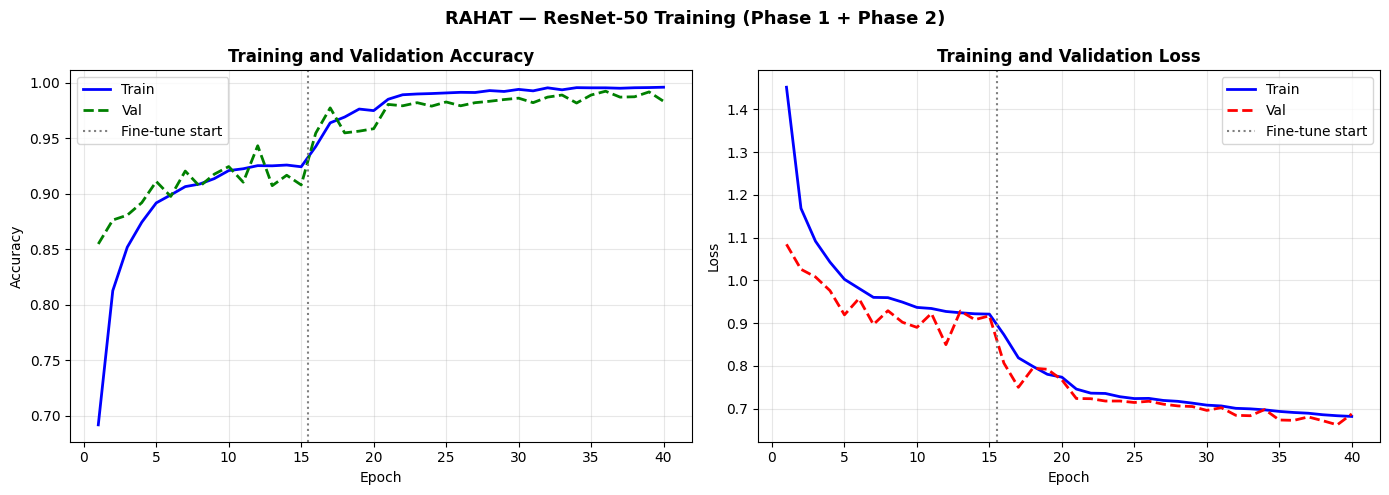

Saved: training_curves.png ✅


In [8]:
# Merge Phase 1 + Phase 2 histories
combined = collections.defaultdict(list)
for key in history_p1.history:
    combined[key] = history_p1.history[key] + history_p2.history.get(key, [])

ep_range = range(1, len(combined['accuracy']) + 1)
p1_end   = len(history_p1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(ep_range, combined['accuracy'],     label='Train', color='blue',  lw=2)
ax1.plot(ep_range, combined['val_accuracy'], label='Val',   color='green', lw=2, ls='--')
ax1.axvline(x=p1_end+0.5, color='gray', ls=':', lw=1.5, label='Fine-tune start')
ax1.set_title('Training and Validation Accuracy', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(ep_range, combined['loss'],     label='Train', color='blue', lw=2)
ax2.plot(ep_range, combined['val_loss'], label='Val',   color='red',  lw=2, ls='--')
ax2.axvline(x=p1_end+0.5, color='gray', ls=':', lw=1.5, label='Fine-tune start')
ax2.set_title('Training and Validation Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('RAHAT — ResNet-50 Training (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png ✅')

In [9]:
best_model = keras.models.load_model(BEST_CKPT)
print(f'Evaluating: {BEST_CKPT}\n')

val_generator.reset()
y_probs = best_model.predict(val_generator, steps=STEPS_VAL, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = val_generator.classes[:len(y_pred)]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('='*58)
print('  RAHAT — ResNet-50 Results  vs  Paper (Table 1)')
print('='*58)
print(f'  Accuracy  : {acc:.4f}   (Paper: 0.9714)')
print(f'  Precision : {prec:.4f}   (Paper: 0.9727)')
print(f'  Recall    : {rec:.4f}   (Paper: 0.9714)')
print(f'  F1-Score  : {f1:.4f}   (Paper: 0.9714)')
print('='*58)

label_names = [
    c.replace('Tomato__','').replace('Tomato_','').replace('_',' ')
    for c in CLASS_LABELS
]
print('\nPer-class Report:')
print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

Evaluating: /kaggle/working/resnet50_phase2_best.keras

100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step
  RAHAT — ResNet-50 Results  vs  Paper (Table 1)
  Accuracy  : 0.9925   (Paper: 0.9714)
  Precision : 0.9926   (Paper: 0.9727)
  Recall    : 0.9925   (Paper: 0.9714)
  F1-Score  : 0.9925   (Paper: 0.9714)

Per-class Report:
                                      precision    recall  f1-score   support

                      Bacterial spot       1.00      0.99      0.99       425
                        Early blight       0.98      0.99      0.99       200
                         Late blight       1.00      1.00      1.00       381
                           Leaf Mold       1.00      1.00      1.00       190
                  Septoria leaf spot       0.99      1.00      1.00       354
Spider mites Two spotted spider mite       0.99      0.99      0.99       335
                         Target Spot       0.99      0.95      0.97       280
              YellowLeaf  Curl Virus       1.00    

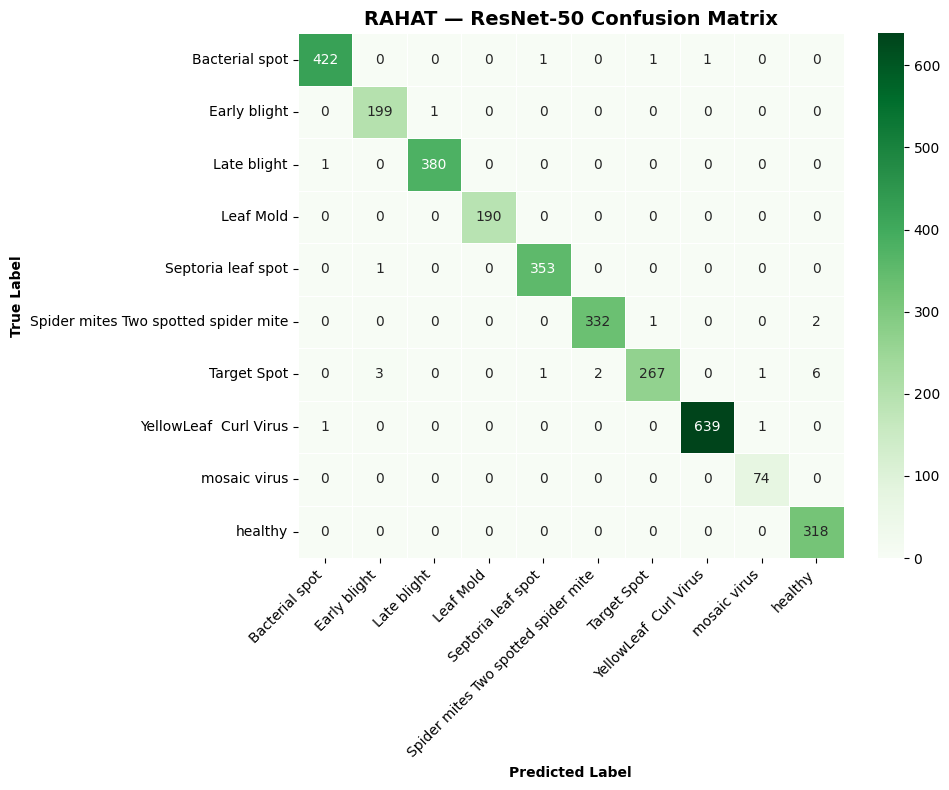

Saved: confusion_matrix.png ✅


In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Greens',
    xticklabels = label_names,
    yticklabels = label_names,
    linewidths  = 0.5
)
plt.title('RAHAT — ResNet-50 Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png ✅')

In [11]:
import shutil

# Copy best model to final output name
shutil.copy(BEST_CKPT, '/kaggle/working/resnet50_rahat_final.keras')

# Treatment info dictionary
class_info = {
    'Tomato_Bacterial_spot'                      : 'Bacterial Spot — Copper-based sprays, remove infected leaves',
    'Tomato_Early_blight'                        : 'Early Blight — Apply mancozeb or chlorothalonil fungicide',
    'Tomato_Late_blight'                         : 'Late Blight — Remove infected parts immediately, apply fungicide',
    'Tomato_Septoria_leaf_spot'                  : 'Septoria Leaf Spot — Apply copper fungicide, avoid overhead watering',
    'Tomato__Tomato_YellowLeaf__Curl_Virus'      : 'Yellow Leaf Curl — Remove infected plants, control whitefly vectors',
    'Tomato__Tomato_mosaic_virus'                : 'Mosaic Virus — No cure; remove & destroy infected plants',
    'Tomato_healthy'                             : 'Healthy — No treatment needed',
    'Tomato_Leaf_Mold'                           : 'Leaf Mold — Improve airflow, apply copper fungicide',
    'Tomato_Spider_mites_Two_spotted_spider_mite': 'Spider Mites — Miticide spray, increase humidity',
    'Tomato__Target_Spot'                        : 'Target Spot — Apply copper or mancozeb fungicide',
    'Pepper__bell___Bacterial_spot'              : 'Bacterial Spot — Copper-based fungicides',
    'Pepper__bell___healthy'                     : 'Healthy — No treatment needed',
    'Potato___Early_blight'                      : 'Early Blight — Apply mancozeb fungicide',
    'Potato___Late_blight'                       : 'Late Blight — Apply chlorothalonil fungicide',
    'Potato___healthy'                           : 'Healthy — No treatment needed',
}

joblib.dump(CLASS_LABELS, '/kaggle/working/disease_class_labels.pkl')
joblib.dump(class_info,   '/kaggle/working/disease_class_info.pkl')

# Print output file sizes
output_files = [
    'resnet50_rahat_final.keras',
    'resnet50_phase1_best.keras',
    'resnet50_phase2_best.keras',
    'disease_class_labels.pkl',
    'disease_class_info.pkl',
    'training_curves.png',
    'confusion_matrix.png',
]

print('Output files:')
for f in output_files:
    path = f'/kaggle/working/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024 / 1024
        print(f'  ✅  {f:<45}  {size:.1f} MB')
    else:
        print(f'  ⚠️  {f:<45}  NOT FOUND')

print('\n⬇️  Download from the Output tab → Save Version first!')

Output files:
  ✅  resnet50_rahat_final.keras                     214.3 MB
  ✅  resnet50_phase1_best.keras                     104.2 MB
  ✅  resnet50_phase2_best.keras                     214.3 MB
  ✅  disease_class_labels.pkl                       0.0 MB
  ✅  disease_class_info.pkl                         0.0 MB
  ✅  training_curves.png                            0.1 MB
  ✅  confusion_matrix.png                           0.1 MB

⬇️  Download from the Output tab → Save Version first!


Testing on: /kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Early_blight/860f1131-a11c-4e17-aaec-c7b96ba914f0___RS_Erly.B 6669.JPG



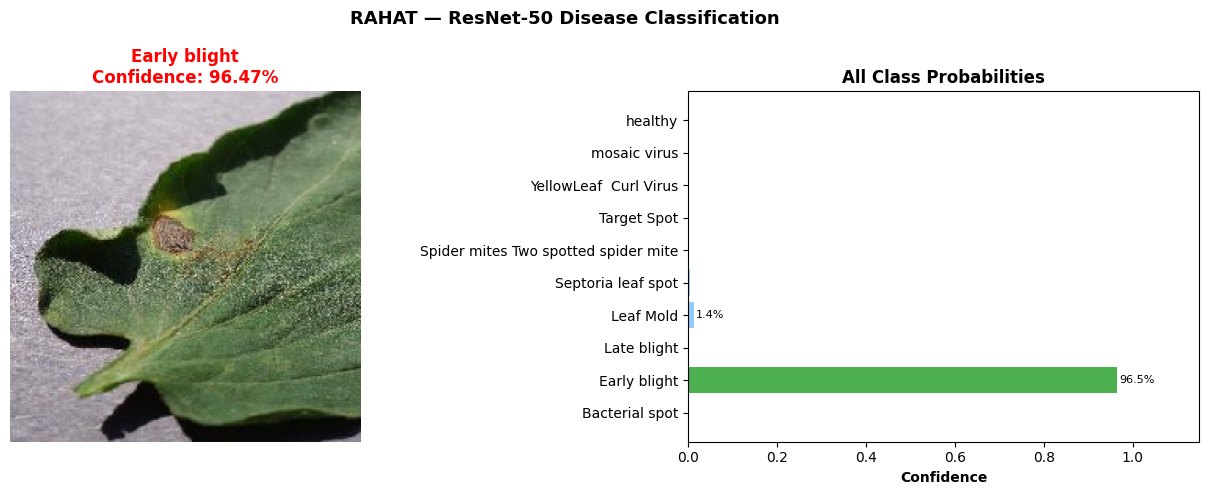

  Disease    : Early blight
  Confidence : 96.47%
  Treatment  : Early Blight — Apply mancozeb or chlorothalonil fungicide
  → Next     : GPT-3.5 detailed recommendation


('Tomato_Early_blight', np.float32(0.96471703))

In [12]:
from tensorflow.keras.preprocessing import image as keras_image

# Load saved model + labels
loaded_model  = keras.models.load_model('/kaggle/working/resnet50_rahat_final.keras')
loaded_labels = joblib.load('/kaggle/working/disease_class_labels.pkl')
loaded_info   = joblib.load('/kaggle/working/disease_class_info.pkl')

def predict_leaf(img_path):
    """
    Predict tomato disease from a leaf image path.
    Works with any image from /kaggle/input/ or uploaded images.
    """
    # Load and preprocess
    img       = keras_image.load_img(img_path, target_size=(224, 224))
    arr       = keras_image.img_to_array(img)
    arr       = np.expand_dims(arr, axis=0)
    arr       = preprocess_input(arr)

    # Predict
    probs     = loaded_model.predict(arr, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    pred_cls  = loaded_labels[pred_idx]
    conf      = probs[pred_idx]
    short     = pred_cls.replace('Tomato__','').replace('Tomato_','').replace('_',' ')
    treatment = loaded_info.get(pred_cls, 'Consult agricultural expert')

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.imshow(img)
    color = 'green' if 'healthy' in pred_cls.lower() else 'red'
    ax1.set_title(
        f'{short}\nConfidence: {conf:.2%}',
        fontweight='bold', color=color, fontsize=12
    )
    ax1.axis('off')

    short_names = [
        l.replace('Tomato__','').replace('Tomato_','').replace('_',' ')
        for l in loaded_labels
    ]
    colors = ['#4CAF50' if i == pred_idx else '#90CAF9' for i in range(len(loaded_labels))]
    bars   = ax2.barh(short_names, probs, color=colors)
    for bar, val in zip(bars, probs):
        if val > 0.01:
            ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.1%}', va='center', fontsize=8)
    ax2.set_xlim(0, 1.15)
    ax2.set_xlabel('Confidence', fontweight='bold')
    ax2.set_title('All Class Probabilities', fontweight='bold')

    plt.suptitle('RAHAT — ResNet-50 Disease Classification', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('='*50)
    print(f'  Disease    : {short}')
    print(f'  Confidence : {conf:.2%}')
    print(f'  Treatment  : {treatment}')
    print(f'  → Next     : GPT-3.5 detailed recommendation')
    print('='*50)
    return pred_cls, conf


# ── Test on a random image from the dataset ────────────────────────
random.seed(42)
test_cls = random.choice(CLASS_NAMES)
test_dir = os.path.join(DATASET_PATH, test_cls)
test_img = os.path.join(test_dir, random.choice(os.listdir(test_dir)))

print(f'Testing on: {test_img}\n')
predict_leaf(test_img)